In [5]:
import pandas as pd 
import numpy as np


In [6]:
df_mat = pd.read_csv('data/student-mat.csv', sep=';')
df_por = pd.read_csv('data/student-por.csv', sep=';')

# Tag each row with its subject so the model can distinguish them
df_mat['subject'] = 'mat'
df_por['subject'] = 'por'

df = pd.concat([df_mat, df_por], ignore_index=True)

# Ensuring grade columns are numeric (they can be quoted strings)
for col in ['G1', 'G2', 'G3']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Dropping rows where G3 is missing (a handful in the combined set)
df.dropna(subset=['G3'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Mat rows  : {len(df_mat)}')
print(f'Por rows  : {len(df_por)}')
print(f'Combined  : {df.shape[0]} students x {df.shape[1]} columns')
print(f'Columns   : {list(df.columns)}')

Mat rows  : 395
Por rows  : 649
Combined  : 1044 students x 34 columns
Columns   : ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject']


In [7]:
binary_cols = ['sex', 'address', 'famsize', 'Pstatus', 'school', 'subject','schoolsup', 'famsup', 'paid', 'activities',
 'nursery','higher','internet',
 'romantic']
ohe_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

In [8]:
x= [i for i in df.columns if i not in (binary_cols + ohe_cols)]
x

['age',
 'Medu',
 'Fedu',
 'traveltime',
 'studytime',
 'failures',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [9]:
df['Total_Alcohol']   = df['Dalc'] + df['Walc']
df['Parent_Edu_Sum']  = df['Medu'] + df['Fedu']
df['Social_Life']     = df['goout'] + df['freetime']

# SUPPORT & BEHAVIOUR — binary encoding
for col in ['schoolsup', 'famsup', 'paid', 'activities', 'internet',
            'higher', 'nursery', 'romantic']:
    df[col + '_bin'] = df[col].map({'yes': 1, 'no': 0})

df['Study_Support'] = df['schoolsup_bin'] + df['famsup_bin'] + df['paid_bin']

# RATIO / EFFICIENCY FEATURES
df['Study_vs_Social']  = df['studytime'] / (df['Social_Life'] + 1)
df['Study_per_Absent'] = df['studytime'] / (df['absences'] + 1)
df['Support_per_Fail'] = df['Study_Support'] / (df['failures'] + 1)

# COMPOUND RISK FEATURES
df['Fail_Burden']   = df['failures'] * df['Total_Alcohol']
df['Health_Absence'] = df['health'] * df['absences']
df['Risk_Index']    = (df['failures'] * 2 +
                       df['Total_Alcohol'] +
                       df['absences'] / 10 +
                       (5 - df['health']))

# GRADE TRAJECTORY — CONTINUOUS (G1 & G2 kept as raw scores)

df['G1_norm']       = df['G1'] / 20.0          # normalise to [0, 1]
df['G2_norm']       = df['G2'] / 20.0
df['G2_G1_delta']   = df['G2'] - df['G1']      # grade change between periods
df['G_avg_P1P2']    = (df['G1'] + df['G2']) / 2.0
df['G1_below_pass'] = (df['G1'] < 10).astype(int)   # soft risk flag (binary, not category)
df['G2_below_pass'] = (df['G2'] < 10).astype(int)
df['Both_failing']  = df['G1_below_pass'] * df['G2_below_pass']

# 3-F  POLYNOMIAL / INTERACTION
df['studytime_sq']   = df['studytime'] ** 2
df['absences_log']   = np.log1p(df['absences'])
df['age_failures']   = df['age'] * df['failures']
df['parent_support'] = df['Parent_Edu_Sum'] * df['Study_Support']
df['Risk_Flag']=(df['G3']<10).astype(int)


print('Feature engineering complete')
print(f'Total columns after engineering: {df.shape[1]}')

Feature engineering complete
Total columns after engineering: 64


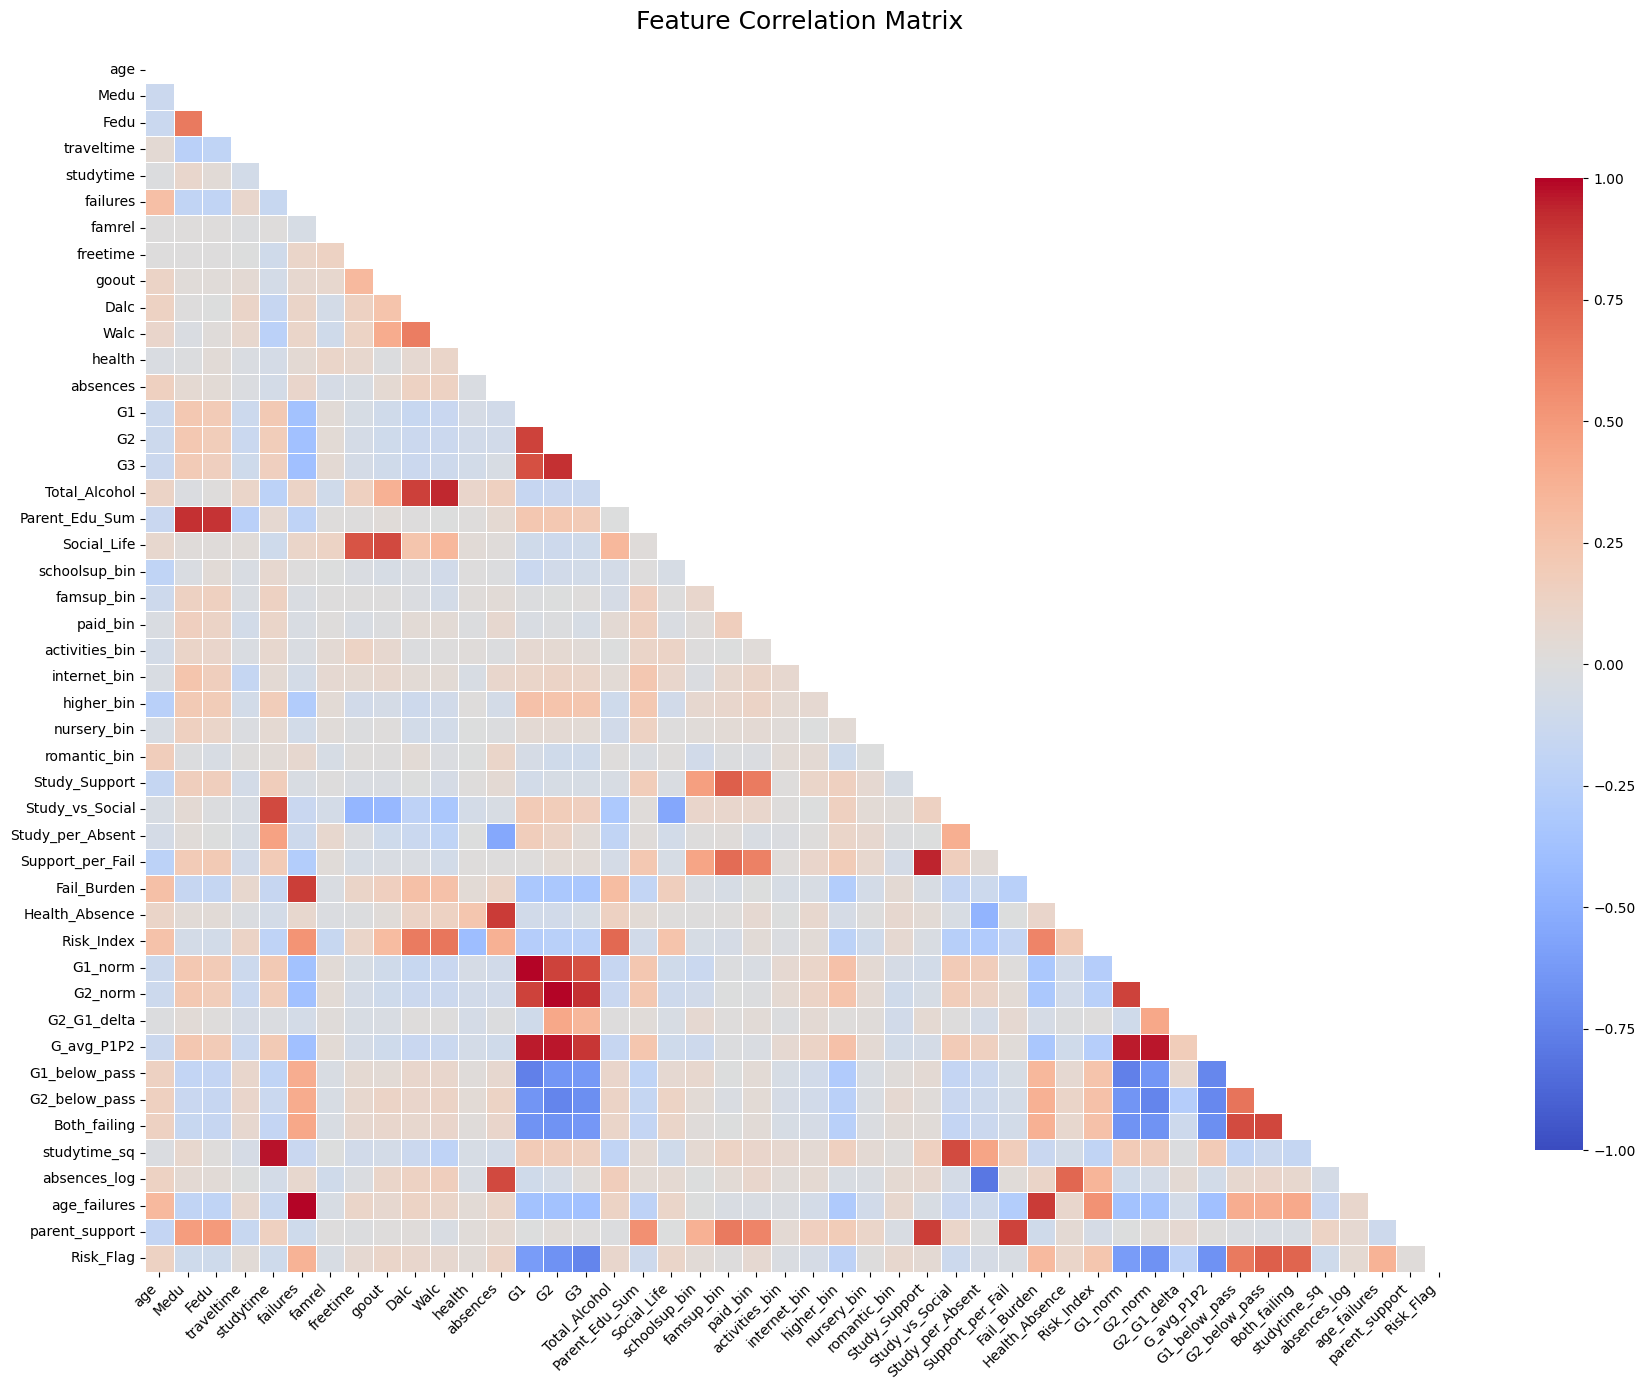

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filter for numeric columns only (correlation requires numbers)
numeric_df = df.select_dtypes(include=[np.number])

# 2. Calculate the Pearson correlation matrix
corr_matrix = numeric_df.corr()

# 3. Set up the figure size (make it large enough since you have many features)
plt.figure(figsize=(18, 14))

# 4. Generate a mask for the upper triangle (optional, but makes it easier to read)
# This hides the duplicate mirrored correlations on the top right
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=False,         # Change to True if you want the exact numbers printed in the boxes
    cmap='coolwarm',     # Red = highly positively correlated, Blue = negatively correlated
    vmin=-1, vmax=1,     # Lock the scale from -1 to 1
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Feature Correlation Matrix', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


In [11]:
columns_to_drop = [
    'G3', 
    'Dalc', 'Walc', 'Medu', 'Fedu', 'goout', 'freetime',
    'G1_norm', 'G2_norm', 'G_avg_P1P2', 'studytime_sq', 'absences',
    'Risk_Index', 'Fail_Burden'
]

df_clean = df.drop(columns=columns_to_drop)


Risk_Flag Distribution:
Risk_Flag
0    814
1    230
Name: count, dtype: int64

Percentage Split:
Risk_Flag
0    77.969349
1    22.030651
Name: proportion, dtype: float64


/var/folders/9k/2_1j0r1d58s_zqvkn0_jmwf80000gn/T/ipykernel_6838/2931229373.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Risk_Flag', palette='viridis')


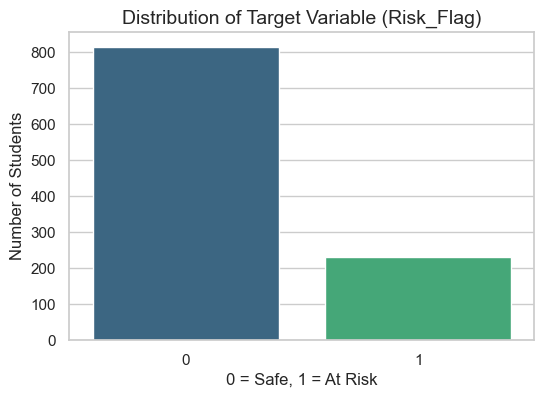

In [12]:


# Set a clean visual style
sns.set_theme(style="whitegrid")

# Print the exact numbers and percentages
print("Risk_Flag Distribution:")
print(df_clean['Risk_Flag'].value_counts())
print("\nPercentage Split:")
print(df_clean['Risk_Flag'].value_counts(normalize=True) * 100)

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Risk_Flag', palette='viridis')
plt.title('Distribution of Target Variable (Risk_Flag)', fontsize=14)
plt.xlabel('0 = Safe, 1 = At Risk', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.show()


/var/folders/9k/2_1j0r1d58s_zqvkn0_jmwf80000gn/T/ipykernel_6838/2594447742.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/9k/2_1j0r1d58s_zqvkn0_jmwf80000gn/T/ipykernel_6838/2594447742.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/9k/2_1j0r1d58s_zqvkn0_jmwf80000gn/T/ipykernel_6838/2594447742.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/9k/2_1j0r1d58s_zqvkn0_jmwf80000gn/T/ipykernel_6838/2594447742.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

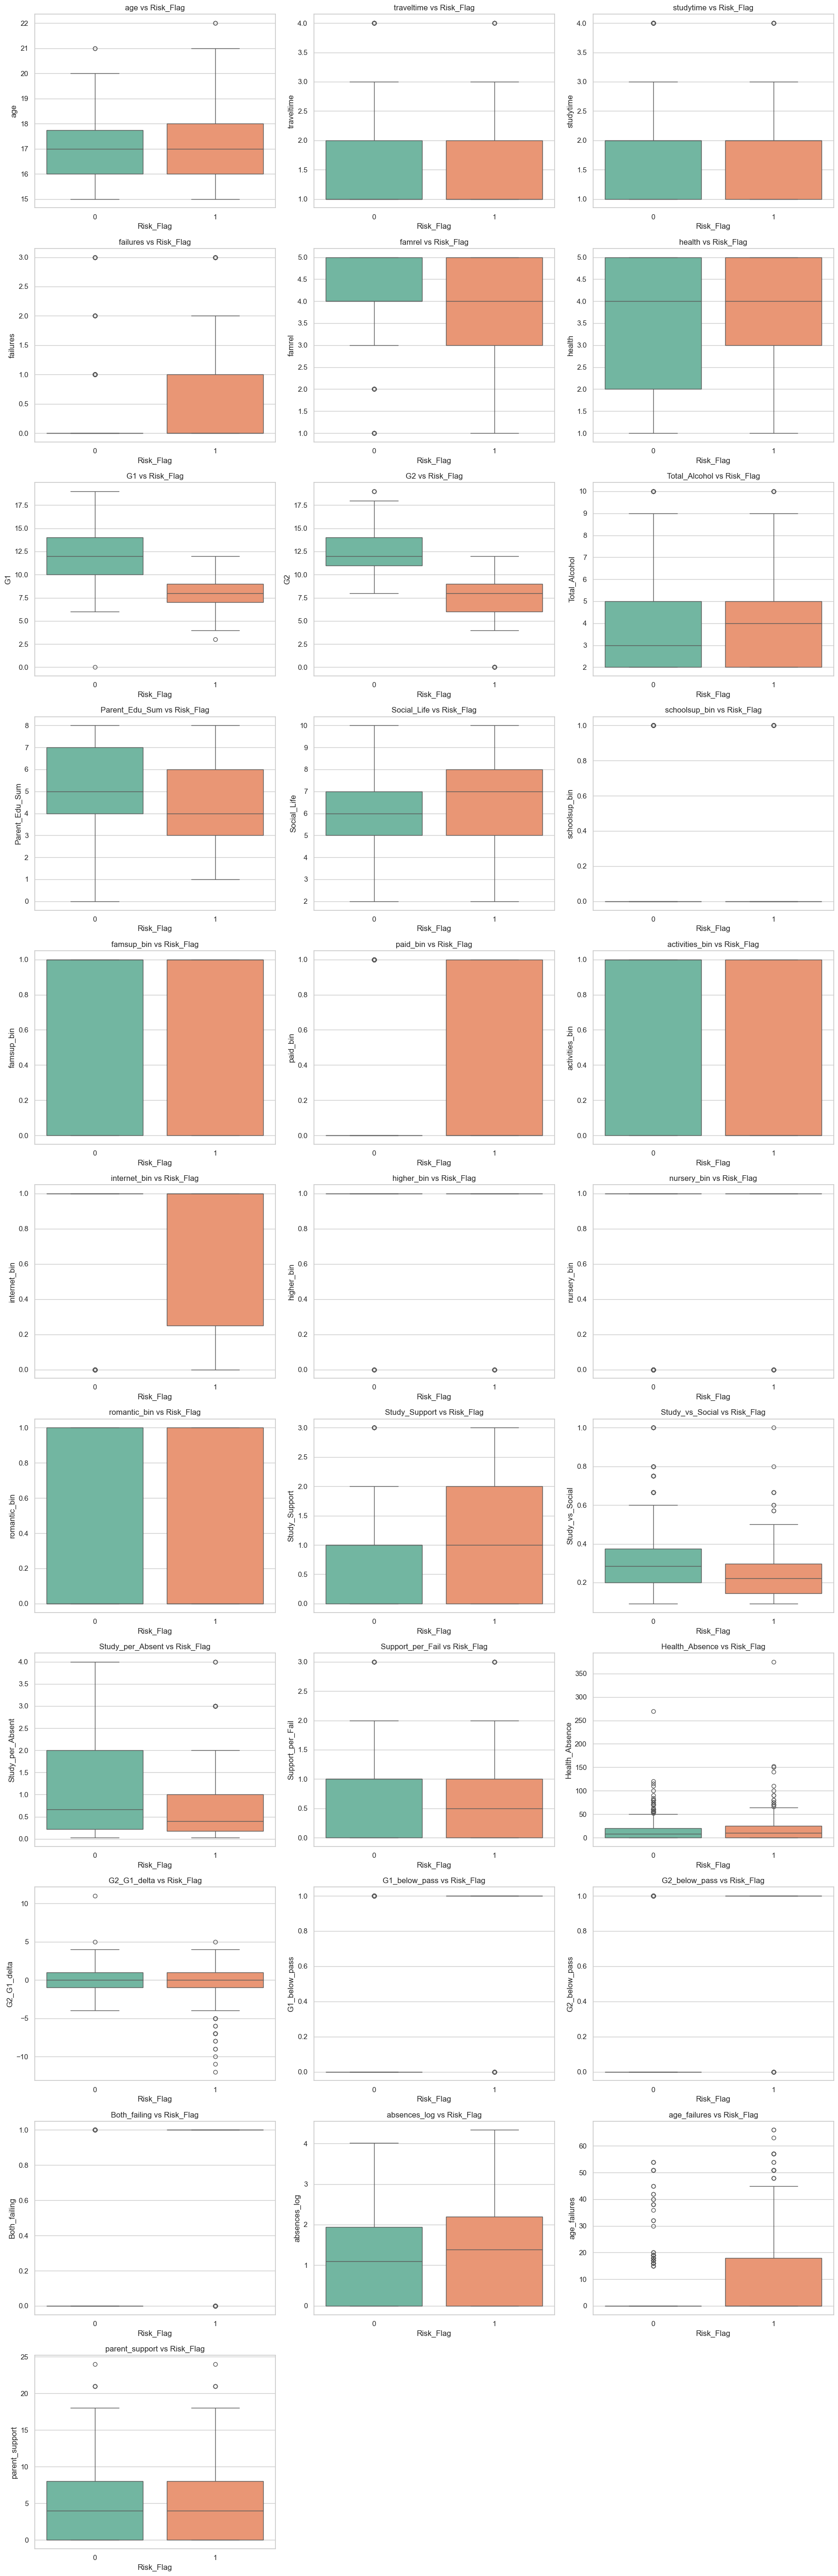

In [13]:


# Select only numeric columns, ignoring the target itself
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.drop('Risk_Flag', errors='ignore')

num_cols = 3
num_rows = int(np.ceil(len(numeric_features) / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(
        data=df_clean, 
        x='Risk_Flag', 
        y=col, 
        ax=axes[i], 
        palette='Set2'
    )
    axes[i].set_title(f'{col} vs Risk_Flag', fontsize=12)
    axes[i].set_xlabel('Risk_Flag')
    axes[i].set_ylabel(col)

# Hide any unused subplots if the number of features isn't a perfect multiple of num_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


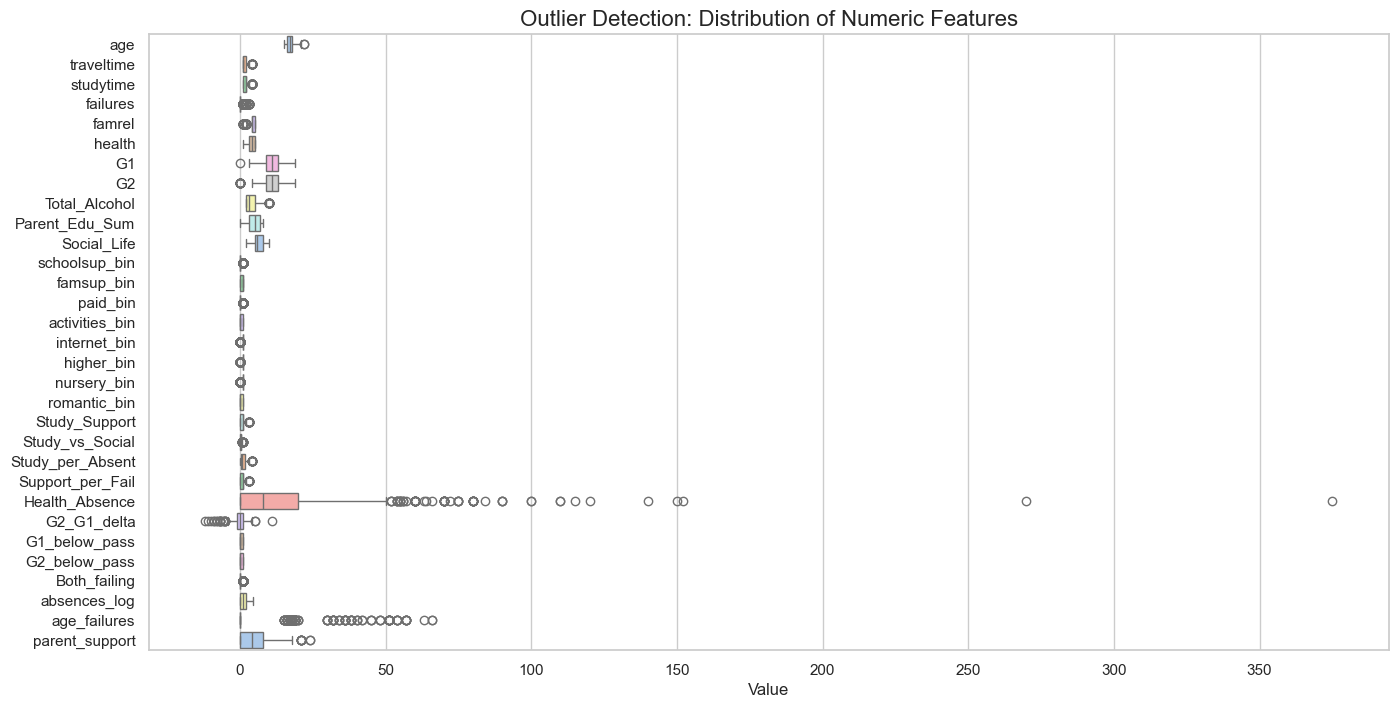

In [14]:
plt.figure(figsize=(16, 8))

# Create a horizontal boxplot for all numeric features
sns.boxplot(
    data=df_clean[numeric_features], 
    orient="h", 
    palette="pastel"
)

plt.title('Outlier Detection: Distribution of Numeric Features', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.show()


In [15]:
import optuna
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

def evaluate_and_report(model, X_test_data, y_test_data, model_name):
    print(f"\n{'='*50}")
    print(f"--- EVALUATING: {model_name} ---")
    print(f"{'='*50}")
    
    # 1. Get probabilities
    y_probs = model.predict_proba(X_test_data)[:, 1]
    
    # 2. Calculate the optimal F1 threshold
    precisions, recalls, thresholds = precision_recall_curve(y_test_data, y_probs)
    f1_arr = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_thresh_idx = np.argmax(f1_arr[:-1])
    best_threshold = float(thresholds[best_thresh_idx])
    
    print(f"Optimal F1 Threshold: {best_threshold:.3f}\n")
    
    # 3. Generate predictions using this tuned threshold
    y_pred_tuned = (y_probs >= best_threshold).astype(int)
    
    # 4. Print the final report
    report = classification_report(y_test_data, y_pred_tuned, target_names=['Safe (0)', 'At-Risk (1)'])
    print(report)


/Users/tanay/Desktop/FAILSAFE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

def evaluate_classification_metrics(y_true, y_pred):
    """
    Calculates and prints accuracy, precision, and F1 score for a classification model.
    
    Parameters:
    y_true (array-like): True labels of the data.
    y_pred (array-like): Predicted labels returned by the classifier.
    
    Returns:
    dict: A dictionary containing the calculated metric scores.
    """
    # Calculate metrics
    # average='binary' is the default and calculates metrics for the class labeled '1'
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    
    
    # Print formatted results
    print("-" * 30)
    print("Classification Metrics")
    print("-" * 30)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 30)
    
    # Return as a dictionary in case you want to save them to a variable later
    return {
        'accuracy': accuracy,
        'precision': precision,
        'f1_score': f1
    }




In [17]:
def run_optuna_study(X_train_data, y_train_data, preprocessor_obj):
    # Calculate scale_weight dynamically based on the passed-in data
    scale_weight = (y_train_data == 0).sum() / (y_train_data == 1).sum()
    
    def objective(trial):
        param = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'random_state': 42,
            'scale_pos_weight': scale_weight,
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 7)
        }
        
        xgb_model = xgb.XGBClassifier(**param)
        pipeline = Pipeline(steps=[('preprocessor', preprocessor_obj), ('classifier', xgb_model)])
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        scores = cross_val_score(pipeline, X_train_data, y_train_data, cv=cv, scoring='roc_auc', n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    
    print(f"Best ROC-AUC: {study.best_value:.4f}")
    return study.best_params



In [18]:
import shap
import matplotlib.pyplot as plt

def generate_shap_plot(model, X_test_data, preprocessor_obj, title):
    # 1. Extract the raw XGBoost model and preprocessor
    extracted_xgb = model.named_steps['classifier']
    
    # 2. Transform the test data using the specific preprocessor
    X_test_ready = preprocessor_obj.transform(X_test_data)
    
    # 3. Get the expanded One-Hot Encoded names
    encoded_feature_names = preprocessor_obj.get_feature_names_out()
    
    # 4. Calculate SHAP values
    explainer = shap.TreeExplainer(extracted_xgb)
    shap_values = explainer.shap_values(X_test_ready)
    
    # 5. Generate the plot
    plt.figure(figsize=(9, 6))
    plt.title(title, fontsize=14, pad=15)
    shap.summary_plot(shap_values, X_test_ready, feature_names=encoded_feature_names, show=False)
    plt.tight_layout()
    plt.show()


In [19]:
from sklearn.model_selection import train_test_split

# 1. Separate your features (X) from your target (y)
X_g2 = df_clean.drop(columns=['Risk_Flag'])
y_g2 = df_clean['Risk_Flag']

# 2. Perform the split
# Using stratify=y is CRUCIAL for imbalanced datasets
X_train_g2, X_test_g2, y_train_g2, y_test_g2 = train_test_split(
    X_g2, 
    y_g2, 
    test_size=0.2,       # Reserves 20% of the data for final testing
    random_state=42,     # Ensures you get the exact same split if you run it again
    stratify=y_g2          # Forces the 80/20 split to maintain your exact Class 0 / Class 1 ratio
)

print(f"Training data shape: {X_train_g2.shape}")
print(f"Testing data shape: {X_test_g2.shape}")

Training data shape: (835, 49)
Testing data shape: (209, 49)


In [20]:
binary_cols = ['sex', 'address', 'famsize', 'Pstatus', 'school', 'subject','schoolsup', 'famsup', 'paid', 'activities',
 'nursery','higher','internet',
 'romantic','G1_below_pass','G2_below_pass']
ohe_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split,StratifiedKFold, GridSearchCV


preprocessor_g2 = ColumnTransformer(
    transformers=[
   
        ('binary', OrdinalEncoder(dtype=float), binary_cols), 
        
       
        # sparse_output=False ensures it returns an array XGBoost can read, not a sparse matrix
        ('ohe', OneHotEncoder(drop='first', sparse_output=False, dtype=float), ohe_cols) 
    ],
    # 'passthrough' ensures your other numeric columns (e.g., age, G1, G2, absences) 
   
    remainder='passthrough' 
)

[I 2026-06-14 18:48:37,642] A new study created in memory with name: no-name-c86ed765-1d8b-4ca4-af33-1d5890d341d6


--- G2 Final Checkpoint Model ---


Best trial: 0. Best value: 0.966249:   2%|▏         | 1/50 [00:01<01:15,  1.54s/it]

[I 2026-06-14 18:48:39,191] Trial 0 finished with value: 0.9662488912870593 and parameters: {'n_estimators': 286, 'max_depth': 6, 'learning_rate': 0.028417961382032435, 'subsample': 0.6520233580719174, 'colsample_bytree': 0.8430547988444392, 'gamma': 2.131074791149912, 'min_child_weight': 7}. Best is trial 0 with value: 0.9662488912870593.


Best trial: 2. Best value: 0.968951:   4%|▍         | 2/50 [00:02<01:02,  1.31s/it]

...

[I 2026-06-14 18:48:43,888] Trial 41 finished with value: 0.9717964411857543 and parameters: {'n_estimators': 193, 'max_depth': 6, 'learning_rate': 0.014784607062911913, 'subsample': 0.6298332920713403, 'colsample_bytree': 0.7664191975489398, 'gamma': 3.368144106667868, 'min_child_weight': 7}. Best is trial 41 with value: 0.9717964411857543.
[I 2026-06-14 18:48:43,946] Trial 42 finished with value: 0.9703345094948148 and parameters: {'n_estimators': 227, 'max_depth': 6, 'learning_rate': 0.015639759939226804, 'subsample': 0.6965680515678048, 'colsample_bytree': 0.832350763261529, 'gamma': 3.63263965204328, 'min_child_weight': 7}. Best is trial 41 with value: 0.9717964411857543.
[I 2026-06-14 18:48:44,003] Trial 43 finished with value: 0.9698380353342186 and parameters: {'n_estimators': 186, 'max_depth': 7, 'learning_rate': 0.019139295883267758, 'subsample': 0.6325407292523808, 'colsample_bytree': 0.8543507836753621, 'gamma': 3.318963055091075, 'min_child_weight': 7}. Best is trial 41 wi

Best trial: 47. Best value: 0.972129:  96%|█████████▌| 48/50 [00:06<00:00, 15.91it/s]

[I 2026-06-14 18:48:44,129] Trial 45 finished with value: 0.969005605723163 and parameters: {'n_estimators': 390, 'max_depth': 7, 'learning_rate': 0.02017489802821213, 'subsample': 0.6946862165463055, 'colsample_bytree': 0.774019557273742, 'gamma': 4.927562420511264, 'min_child_weight': 7}. Best is trial 41 with value: 0.9717964411857543.
[I 2026-06-14 18:48:44,188] Trial 46 finished with value: 0.9695461462637034 and parameters: {'n_estimators': 139, 'max_depth': 5, 'learning_rate': 0.011134496187326466, 'subsample': 0.6180293088339136, 'colsample_bytree': 0.9417837557306892, 'gamma': 3.3222139764833183, 'min_child_weight': 6}. Best is trial 41 with value: 0.9717964411857543.
[I 2026-06-14 18:48:44,245] Trial 47 finished with value: 0.9721290815183945 and parameters: {'n_estimators': 196, 'max_depth': 7, 'learning_rate': 0.015605689835955505, 'subsample': 0.650592857830376, 'colsample_bytree': 0.7651913388394236, 'gamma': 4.525451267477637, 'min_child_weight': 7}. Best is trial 47 wit

Best trial: 47. Best value: 0.972129: 100%|██████████| 50/50 [00:06<00:00,  7.47it/s]


[I 2026-06-14 18:48:44,348] Trial 49 finished with value: 0.9704209846957939 and parameters: {'n_estimators': 193, 'max_depth': 8, 'learning_rate': 0.01864604899036414, 'subsample': 0.7095457616835921, 'colsample_bytree': 0.7172748270407512, 'gamma': 4.632704174010192, 'min_child_weight': 6}. Best is trial 47 with value: 0.9721290815183945.
Best ROC-AUC: 0.9721

--- EVALUATING: G2 Final Checkpoint Model ---
Optimal F1 Threshold: 0.397

              precision    recall  f1-score   support

    Safe (0)       0.96      0.93      0.95       163
 At-Risk (1)       0.78      0.87      0.82        46

    accuracy                           0.92       209
   macro avg       0.87      0.90      0.89       209
weighted avg       0.92      0.92      0.92       209



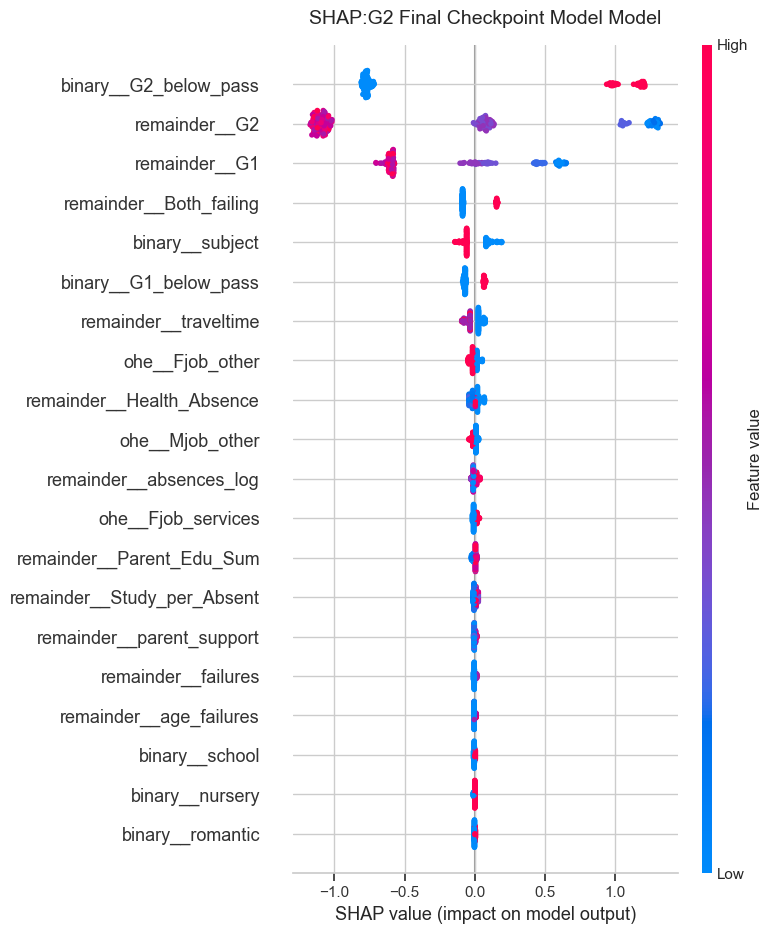

In [22]:
from sklearn.pipeline import Pipeline
import xgboost as xgb

print("==========================================")
print("--- G2 Final Checkpoint Model ---")
print("==========================================")

# 1. Run Optuna to get the best hyperparameters for the Base data
best_params_base = run_optuna_study(X_train_g2, y_train_g2, preprocessor_g2)

# 2. Build the final pipeline with these optimal parameters
final_g2_model = Pipeline(steps=[
    ('preprocessor', preprocessor_g2),
    ('classifier', xgb.XGBClassifier(**best_params_base))
])

# 3. Train the final model
final_g2_model.fit(X_train_g2, y_train_g2)

# 4. Evaluate and generate the Classification Report (Custom Threshold)
evaluate_and_report(final_g2_model, X_test_g2, y_test_g2, "G2 Final Checkpoint Model")

# 5. Generate the SHAP plot
generate_shap_plot(final_g2_model, X_test_g2, preprocessor_g2, "SHAP:G2 Final Checkpoint Model Model")


In [23]:

df_g1 = df_clean.copy()
x=[g for g in df_g1.columns if g.startswith('G2') ]
df_g1 = df_g1.drop(columns=x+['Both_failing'], errors='ignore')
X_g1= df_g1.drop(columns=['Risk_Flag'])
y_g1 = df_g1['Risk_Flag']

# 2. Perform the split
# Using stratify=y is CRUCIAL for imbalanced datasets
X_train_g1, X_test_g1, y_train_g1, y_test_g1 = train_test_split(
    X_g1, 
    y_g1, 
    test_size=0.2,       # Reserves 20% of the data for final testing
    random_state=42,     # Ensures you get the exact same split if you run it again
    stratify=y_g1          # Forces the 80/20 split to maintain your exact Class 0 / Class 1 ratio
)
print(f"Training data shape: {X_train_g1.shape}")
print(f"Testing data shape: {X_test_g1.shape}")

Training data shape: (835, 45)
Testing data shape: (209, 45)


In [24]:
x+['Both_failing']

['G2', 'G2_G1_delta', 'G2_below_pass', 'Both_failing']

In [25]:

binary_cols2 = ['sex', 'address', 'famsize', 'Pstatus', 'school', 'subject','schoolsup', 'famsup', 'paid', 'activities',
 'nursery','higher','internet',
 'romantic','G1_below_pass']
ohe_cols2 = ['Mjob', 'Fjob', 'reason', 'guardian']

In [26]:
preprocessor2 = ColumnTransformer(
    transformers=[
        # Equivalent to your binary dictionary mapping
        ('binary2', OrdinalEncoder(dtype=float), binary_cols2), 
        
        # Equivalent to pd.get_dummies(..., drop_first=True)
        # sparse_output=False ensures it returns an array XGBoost can read, not a sparse matrix
        ('ohe2', OneHotEncoder(drop='first', sparse_output=False, dtype=float), ohe_cols2) 
    ],
    # 'passthrough' ensures your other numeric columns (e.g., age, G1, G2, absences) 
    # aren't dropped and are passed straight to XGBoost
    remainder='passthrough' 
)


[I 2026-06-14 18:48:44,672] A new study created in memory with name: no-name-29aa7b13-f6d8-49ea-a233-8ba09058cc99



--- Tuning G1 Checkpoint Model ---


Best trial: 1. Best value: 0.940945:   2%|▏         | 1/50 [00:00<00:04,  9.97it/s]

[I 2026-06-14 18:48:44,772] Trial 0 finished with value: 0.9383368159704037 and parameters: {'n_estimators': 434, 'max_depth': 6, 'learning_rate': 0.014976582710488087, 'subsample': 0.7997200587411222, 'colsample_bytree': 0.6761913009705206, 'gamma': 0.6297583684339303, 'min_child_weight': 4}. Best is trial 0 with value: 0.9383368159704037.
[I 2026-06-14 18:48:44,824] Trial 1 finished with value: 0.9409454433881915 and parameters: {'n_estimators': 172, 'max_depth': 8, 'learning_rate': 0.010689385684165022, 'subsample': 0.8166775934952197, 'colsample_bytree': 0.6764970814170478, 'gamma': 4.612848194078281, 'min_child_weight': 6}. Best is trial 1 with value: 0.9409454433881915.


Best trial: 4. Best value: 0.941018:   8%|▊         | 4/50 [00:00<00:02, 15.49it/s]

...

[I 2026-06-14 18:48:47,533] Trial 41 finished with value: 0.944546190347717 and parameters: {'n_estimators': 395, 'max_depth': 3, 'learning_rate': 0.012875362463245733, 'subsample': 0.9534917855444365, 'colsample_bytree': 0.6263303593251967, 'gamma': 4.332122891019451, 'min_child_weight': 6}. Best is trial 26 with value: 0.9448114879412589.
[I 2026-06-14 18:48:47,636] Trial 42 finished with value: 0.9440879811108818 and parameters: {'n_estimators': 386, 'max_depth': 3, 'learning_rate': 0.012577188573037787, 'subsample': 0.9581910693047805, 'colsample_bytree': 0.6318252360803353, 'gamma': 4.336388305822275, 'min_child_weight': 6}. Best is trial 26 with value: 0.9448114879412589.
[I 2026-06-14 18:48:47,713] Trial 43 finished with value: 0.9441686548556778 and parameters: {'n_estimators': 457, 'max_depth': 3, 'learning_rate': 0.0168263431895773, 'subsample': 0.9791760665068758, 'colsample_bytree': 0.6219249912185298, 'gamma': 3.817919878148735, 'min_child_weight': 7}. Best is trial 26 wit

Best trial: 26. Best value: 0.944811:  94%|█████████▍| 47/50 [00:03<00:00, 13.60it/s]

[I 2026-06-14 18:48:47,792] Trial 44 finished with value: 0.9439266336212901 and parameters: {'n_estimators': 429, 'max_depth': 3, 'learning_rate': 0.02312751093847842, 'subsample': 0.9447768507298191, 'colsample_bytree': 0.6850299936056654, 'gamma': 4.6746753698628964, 'min_child_weight': 5}. Best is trial 26 with value: 0.9448114879412589.
[I 2026-06-14 18:48:47,864] Trial 45 finished with value: 0.9430809435389588 and parameters: {'n_estimators': 482, 'max_depth': 8, 'learning_rate': 0.03225707098786838, 'subsample': 0.9067782177118342, 'colsample_bytree': 0.6610500838833925, 'gamma': 4.260387934311104, 'min_child_weight': 7}. Best is trial 26 with value: 0.9448114879412589.
[I 2026-06-14 18:48:47,919] Trial 46 finished with value: 0.9424181492120424 and parameters: {'n_estimators': 405, 'max_depth': 4, 'learning_rate': 0.13851503996549672, 'subsample': 0.9327028196342536, 'colsample_bytree': 0.6207514809175283, 'gamma': 3.9215077092133126, 'min_child_weight': 6}. Best is trial 26 w

Best trial: 26. Best value: 0.944811: 100%|██████████| 50/50 [00:03<00:00, 14.48it/s]


[I 2026-06-14 18:48:48,055] Trial 48 finished with value: 0.9421295752593462 and parameters: {'n_estimators': 485, 'max_depth': 4, 'learning_rate': 0.019661508074153834, 'subsample': 0.6034978123140438, 'colsample_bytree': 0.7436194106116113, 'gamma': 3.8084840315558623, 'min_child_weight': 6}. Best is trial 26 with value: 0.9448114879412589.
[I 2026-06-14 18:48:48,125] Trial 49 finished with value: 0.9433295950089843 and parameters: {'n_estimators': 303, 'max_depth': 3, 'learning_rate': 0.01619597846974147, 'subsample': 0.8551286972993193, 'colsample_bytree': 0.6851344321995134, 'gamma': 3.074576599282138, 'min_child_weight': 5}. Best is trial 26 with value: 0.9448114879412589.
Best ROC-AUC: 0.9448

--- EVALUATING: G1 CHECKPOINT MODEL ---
Optimal F1 Threshold: 0.548

              precision    recall  f1-score   support

    Safe (0)       0.93      0.91      0.92       163
 At-Risk (1)       0.70      0.76      0.73        46

    accuracy                           0.88       209
   

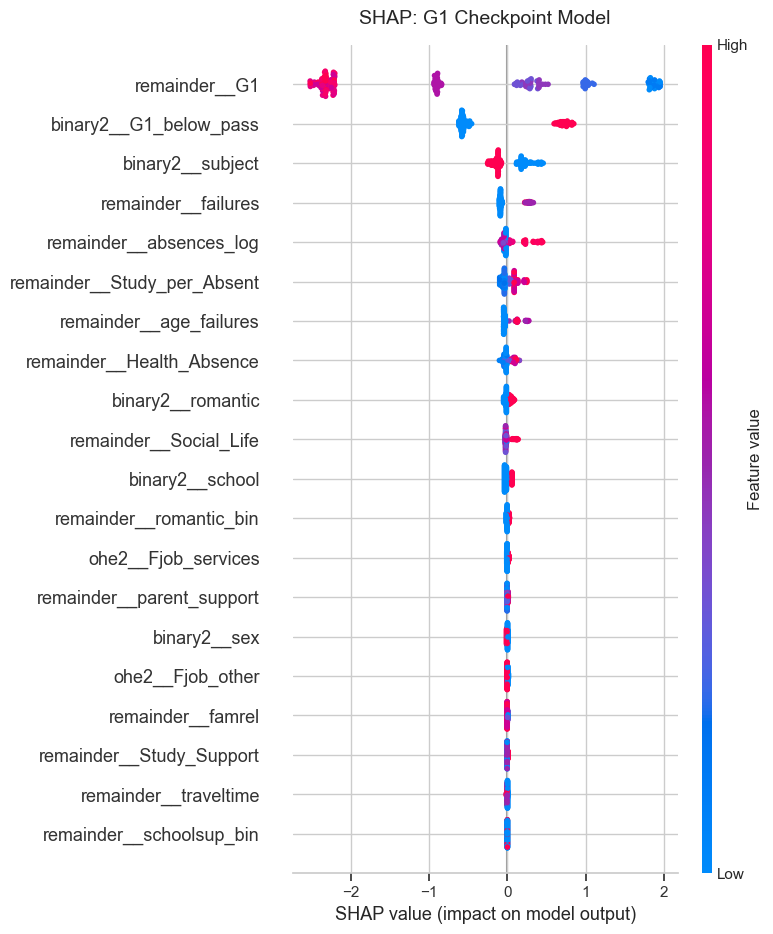

In [27]:
print("\n==========================================")
print("--- Tuning G1 Checkpoint Model ---")
print("==========================================")

# 1. Run Optuna to get the best hyperparameters for the G1 data
best_params_g1= run_optuna_study(X_train_g1, y_train_g1, preprocessor2)

# 2. Build the final pipeline with these optimal parameters
final_g1_model = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', xgb.XGBClassifier(**best_params_g1))
])

# 3. Train the final model
final_g1_model.fit(X_train_g1, y_train_g1)

# 4. Evaluate and generate the Classification Report (Custom Threshold)
evaluate_and_report(final_g1_model, X_test_g2, y_test_g2, "G1 CHECKPOINT MODEL")

# 5. Generate the SHAP plot
generate_shap_plot(final_g1_model, X_test_g2, preprocessor2, "SHAP: G1 Checkpoint Model")


In [28]:
df_demo=df_g1.copy()
cols=[x for x in df_g1 if x.startswith("G1")]
df_demo=df_g1.drop(columns=cols)
X_demo = df_demo.drop(columns=['Risk_Flag'])
y_demo = df_demo['Risk_Flag']


X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, 
    y_demo, 
    test_size=0.2,       # Reserves 20% of the data for final testing
    random_state=42,     # Ensures you get the exact same split if you run it again
    stratify=y_demo          # Forces the 80/20 split to maintain your exact Class 0 / Class 1 ratio
)

print(f"Training data shape: {X_train_demo.shape}")
print(f"Testing data shape: {X_test_demo.shape}")

Training data shape: (835, 43)
Testing data shape: (209, 43)


In [29]:
cols

['G1', 'G1_below_pass']

In [30]:
binary_cols3 = ['sex', 'address', 'famsize', 'Pstatus', 'school', 'subject','schoolsup', 'famsup', 'paid', 'activities',
 'nursery','higher','internet',
 'romantic']
ohe_cols3 = ['Mjob', 'Fjob', 'reason', 'guardian']

In [31]:
preprocessor3 = ColumnTransformer(
    transformers=[
        # Equivalent to your binary dictionary mapping
        ('binary3', OrdinalEncoder(dtype=float), binary_cols3), 
        
        # Equivalent to pd.get_dummies(..., drop_first=True)
        # sparse_output=False ensures it returns an array XGBoost can read, not a sparse matrix
        ('ohe3', OneHotEncoder(drop='first', sparse_output=False, dtype=float), ohe_cols3) 
    ],
    # 'passthrough' ensures your other numeric columns (e.g., age, G1, G2, absences) 
    # aren't dropped and are passed straight to XGBoost
    remainder='passthrough' 
)


In [32]:
print("\n==========================================")
print("--- Tuning Demographic Checkpoint Model ---")
print("==========================================")

# 1. Run Optuna to get the best hyperparameters for the G2 data
best_params_demo = run_optuna_study(X_train_demo, y_train_demo, preprocessor3)

# 2. Build the final pipeline with these optimal parameters
final_demo_model = Pipeline(steps=[
    ('preprocessor', preprocessor3),
    ('classifier', xgb.XGBClassifier(**best_params_g1))
])

# 3. Train the final model
final_demo_model.fit(X_train_demo, y_train_demo)

# 4. Evaluate and generate the Classification Report (Custom Threshold)
evaluate_and_report(final_demo_model, X_test_demo, y_test_demo, "Demographic")

# 5. Generate the SHAP plot



[I 2026-06-14 18:48:48,511] A new study created in memory with name: no-name-0bbb2e63-1b07-4e3d-b7da-2fcd787dff2f



--- Tuning Demographic Checkpoint Model ---


Best trial: 0. Best value: 0.768299:   2%|▏         | 1/50 [00:00<00:06,  8.00it/s]

[I 2026-06-14 18:48:48,636] Trial 0 finished with value: 0.7682986744818805 and parameters: {'n_estimators': 362, 'max_depth': 9, 'learning_rate': 0.04334844646860053, 'subsample': 0.6965498225788017, 'colsample_bytree': 0.9003391218731582, 'gamma': 0.22645184655895823, 'min_child_weight': 1}. Best is trial 0 with value: 0.7682986744818805.
[I 2026-06-14 18:48:48,687] Trial 1 finished with value: 0.7527290825764108 and parameters: {'n_estimators': 197, 'max_depth': 4, 'learning_rate': 0.15431094606394496, 'subsample': 0.8577152732165553, 'colsample_bytree': 0.8411045758488316, 'gamma': 2.3152281108619484, 'min_child_weight': 2}. Best is trial 0 with value: 0.7682986744818805.


Best trial: 3. Best value: 0.777189:   6%|▌         | 3/50 [00:00<00:03, 13.37it/s]

...

Best trial: 31. Best value: 0.794811:  92%|█████████▏| 46/50 [00:03<00:00, 15.32it/s]

[I 2026-06-14 18:48:51,603] Trial 45 finished with value: 0.7741754085265535 and parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.03735596662138992, 'subsample': 0.6247005013500893, 'colsample_bytree': 0.8927725246695649, 'gamma': 0.9982824879175176, 'min_child_weight': 5}. Best is trial 31 with value: 0.7948113997732319.


[I 2026-06-14 18:48:51,664] Trial 46 finished with value: 0.7827781921675051 and parameters: {'n_estimators': 176, 'max_depth': 4, 'learning_rate': 0.01797775011994541, 'subsample': 0.9872848791773641, 'colsample_bytree': 0.8664977065282694, 'gamma': 2.0703216753911153, 'min_child_weight': 6}. Best is trial 31 with value: 0.7948113997732319.
[I 2026-06-14 18:48:51,735] Trial 47 finished with value: 0.7794310693547335 and parameters: {'n_estimators': 122, 'max_depth': 6, 'learning_rate': 0.021889533527314632, 'subsample': 0.8464791238588878, 'colsample_bytree': 0.8039135857211976, 'gamma': 0.4360699168186466, 'min_child_weight': 3}. Best is trial 31 with value: 0.7948113997732319.


Best trial: 31. Best value: 0.794811: 100%|██████████| 50/50 [00:03<00:00, 14.92it/s]


[I 2026-06-14 18:48:51,804] Trial 48 finished with value: 0.788073916547199 and parameters: {'n_estimators': 164, 'max_depth': 6, 'learning_rate': 0.015307666002209522, 'subsample': 0.8115240486933578, 'colsample_bytree': 0.918420798048883, 'gamma': 1.7874723841218412, 'min_child_weight': 6}. Best is trial 31 with value: 0.7948113997732319.
[I 2026-06-14 18:48:51,862] Trial 49 finished with value: 0.7863101504322879 and parameters: {'n_estimators': 141, 'max_depth': 5, 'learning_rate': 0.011939039847785894, 'subsample': 0.7900638992084398, 'colsample_bytree': 0.836449302560432, 'gamma': 1.4499750452439941, 'min_child_weight': 5}. Best is trial 31 with value: 0.7948113997732319.
Best ROC-AUC: 0.7948

--- EVALUATING: Demographic ---
Optimal F1 Threshold: 0.192

              precision    recall  f1-score   support

    Safe (0)       0.90      0.67      0.77       163
 At-Risk (1)       0.39      0.74      0.51        46

    accuracy                           0.68       209
   macro avg

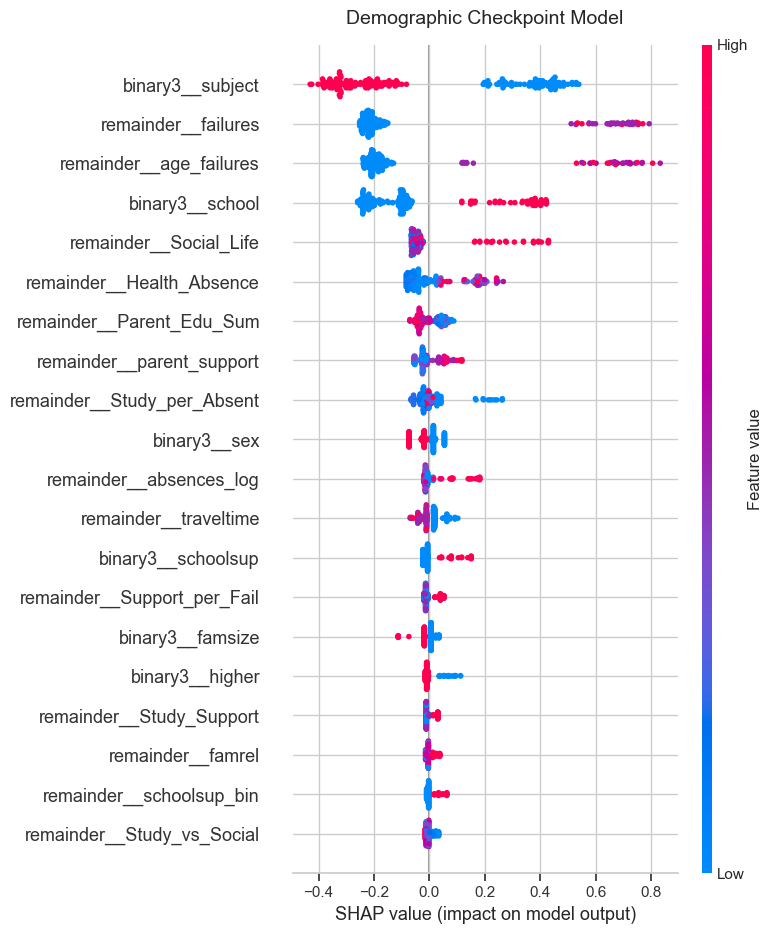

In [33]:
generate_shap_plot(final_demo_model, X_test_demo, preprocessor3, "Demographic Checkpoint Model")

In [34]:
import joblib

# Exporting the three pipelines
# These files will save to your current working directory
joblib.dump(final_demo_model, 'saved_models/failsafe_demo_model.pkl')
joblib.dump(final_g1_model, 'saved_models/failsafe_g1_model.pkl')
joblib.dump(final_g2_model, 'saved_models/failsafe_g2_model.pkl')

print("Success: All three models have been exported as .pkl files.")


Success: All three models have been exported as .pkl files.
